# Notebook Objectives

This notebook loads the behavior data with the trial by trial neural values (computed by the code ```neural_value_RUN_all_sessions.py```).

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)

---
# Setup


In [1]:
from helpers import *
from popy.config import COLORS, PROJECT_PATH_LOCAL

plt.rcParams.update({'font.size': 8})


/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-u5n54ut6 because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


---
# Section 1: Get data (load from file)


In [2]:
behav_new = pd.read_pickle(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', 'behav_neural_value', 'behav.pkl'))
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
# remove 5% outliers from dV
#behav_new = behav_new.loc[behav_new['V_t'].abs() < behav_new['V_t'].abs().quantile(0.95)]
behav_new = behav_new.dropna()

In [3]:
#count nans
behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.150551,0.204889,0.355440,0.283056,0.069825,-0.213231,-0.117508,-0.109746,0.007762
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.204889,-0.059881,-0.264770,0.069825,0.069825,0.000000,-0.109746,-0.055993,0.053753
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.059881,-0.200961,-0.141080,0.069825,0.479459,0.409634,-0.055993,0.064920,0.120912
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.200961,-0.070287,0.130675,0.479459,0.283056,-0.196402,0.064920,-0.083296,-0.148216
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.070287,-0.073770,-0.003484,0.283056,0.167107,-0.115949,-0.083296,0.035119,0.118415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,0.796248,0.689507,-0.106742,0.723918,0.503993,-0.219925,0.706391,-0.005228,-0.711619
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,0.689507,0.057016,-0.632490,0.503993,0.654679,0.150686,-0.005228,0.390832,0.396059
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.057016,0.362536,0.305519,0.654679,0.759587,0.104908,0.390832,0.261081,-0.129750
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.362536,0.786138,0.423602,0.759587,0.832624,0.073037,0.261081,0.440961,0.179879


In [4]:
# normalize dV and V_t per monkey, session, subregion
for time_interval in [(-4, -2), (1.5, 3.5)]:
    behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'dV_{time_interval[0]}_{time_interval[1]}'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] - behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']

behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.769454,0.812984,1.582438,0.283056,0.069825,-0.213231,-0.907589,-0.853688,0.053901
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.811088,-0.362970,-1.174057,0.069825,0.069825,0.000000,-0.848967,-0.447462,0.401505
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.366271,-0.989564,-0.623293,0.069825,0.479459,0.409634,-0.443023,0.466314,0.909337
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.993615,-0.409184,0.584431,0.479459,0.283056,-0.196402,0.470115,-0.653801,-1.123917
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.412541,-0.424657,-0.012115,0.283056,0.167107,-0.115949,-0.649219,0.241101,0.890320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,1.174154,1.031969,-0.142184,0.723918,0.503993,-0.219925,1.895587,-0.036211,-1.931798
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,1.031827,0.190688,-0.841139,0.503993,0.654679,0.150686,-0.031474,1.038479,1.069952
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.188484,0.597062,0.408579,0.654679,0.759587,0.104908,1.041053,0.686407,-0.354646
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.595854,1.160500,0.564645,0.759587,0.832624,0.073037,0.689690,1.174502,0.484812


---
# Section 2: Analysis of the neural value representation

## History in the subspace

### Short history

Using all available CPU cores for parallel processing


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   43.5s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 214 out of 214 | elapsed:  3.8min finished


Analysis complete!
Spearman correlation (rho): 0.815, p-value: 1.0e-111
Spearman correlation positive sequences (rho): 0.357, p-value: 2.2e-08
Spearman correlation negative sequences (rho): 0.544, p-value: 2.7e-19
Spearman correlation (rho): 0.633, p-value: 1.3e-42
Spearman correlation positive sequences (rho): 0.119, p-value: 1.1e-01
Spearman correlation negative sequences (rho): 0.371, p-value: 2.1e-07
Spearman correlation (rho): 0.798, p-value: 2.3e-22
Spearman correlation positive sequences (rho): -0.024, p-value: 8.7e-01
Spearman correlation negative sequences (rho): 0.373, p-value: 9.1e-03
Spearman correlation (rho): 0.828, p-value: 6.0e-104
Spearman correlation positive sequences (rho): 0.173, p-value: 1.3e-02
Spearman correlation negative sequences (rho): 0.634, p-value: 2.4e-24
Spearman correlation (rho): 0.757, p-value: 1.3e-60
Spearman correlation positive sequences (rho): 0.127, p-value: 1.1e-01
Spearman correlation negative sequences (rho): 0.553, p-value: 3.5e-14
Spearman

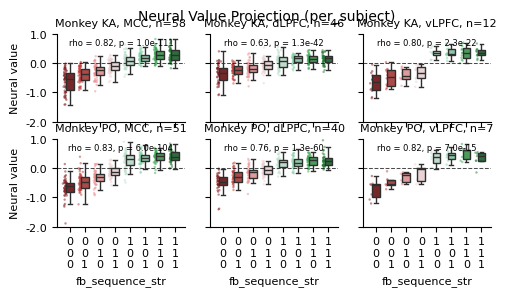

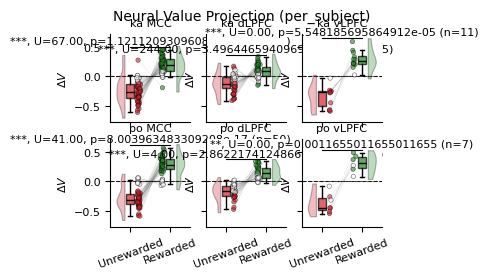

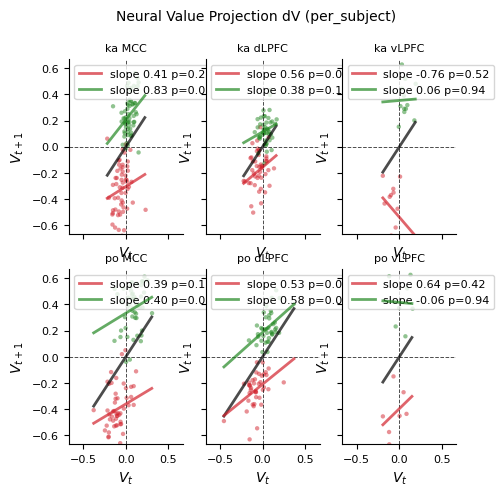

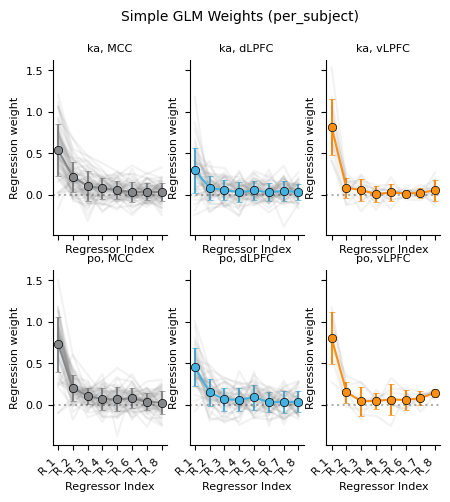

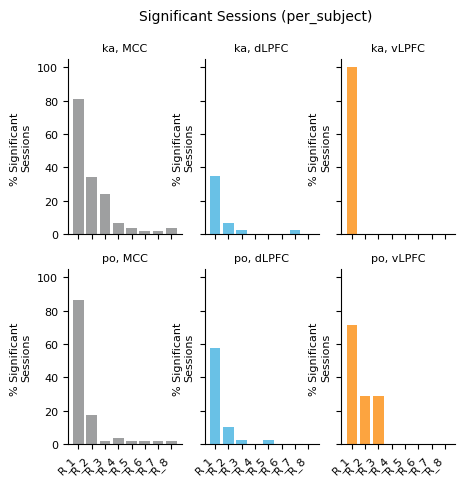

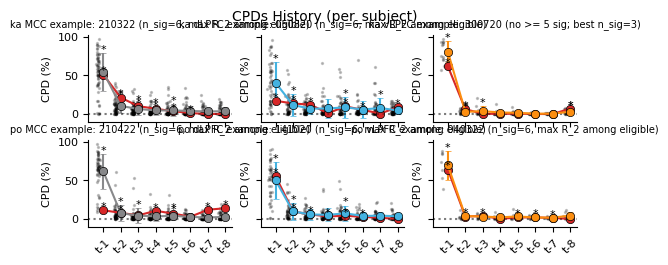

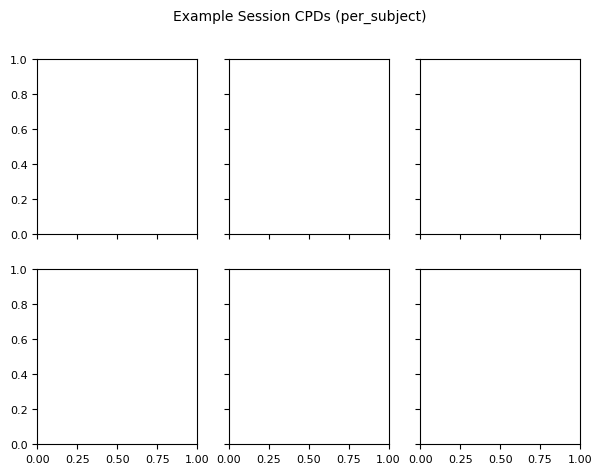

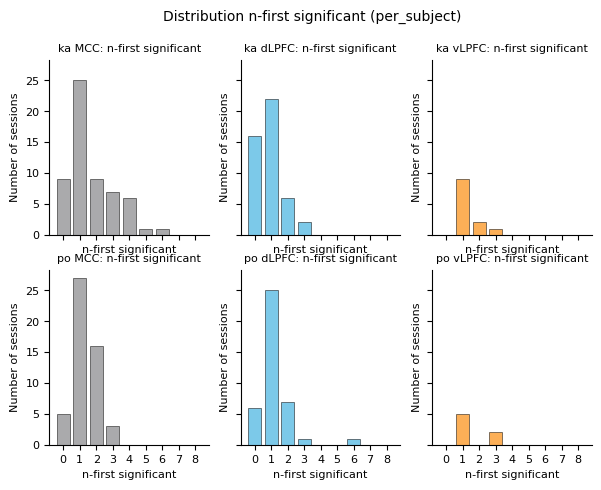

In [22]:

n_perms = 1000  # number of permutations for CPD analysis

time_interval = (1.5, 3.5)
monkey_modes = ['two']#, 'both']

paper_format = True

def plot_example_session_cpds(cpd_temp, ax=None, n_first=5, alpha=0.05, line_color=None):
    axis_original = ax
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2.5, 2))

    if cpd_temp is None or cpd_temp.empty:
        ax.text(0.5, 0.5, 'No CPD data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        if axis_original is None:
            return fig, ax
        return

    monkey = cpd_temp['monkey'].iloc[0] if 'monkey' in cpd_temp.columns else 'unknown'
    subregion = cpd_temp['subregion'].iloc[0] if 'subregion' in cpd_temp.columns else 'unknown'

    cpd_cols = sorted([c for c in cpd_temp.columns if c.startswith('cpd_R_')], key=lambda x: int(x.split('_')[-1]))
    pval_cols = [f"pval_{'_'.join(c.split('_')[1:])}" for c in cpd_cols]

    valid_pairs = [(c_col, p_col) for c_col, p_col in zip(cpd_cols, pval_cols) if p_col in cpd_temp.columns]
    if len(valid_pairs) == 0:
        ax.text(0.5, 0.5, 'No p-value columns found', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        if axis_original is None:
            return fig, ax
        return

    cpd_cols = [c for c, _ in valid_pairs]
    pval_cols = [p for _, p in valid_pairs]
    pval_matrix = cpd_temp[pval_cols].to_numpy()

    sig_counts = (pval_matrix < alpha).sum(axis=1)
    eligible = sig_counts >= n_first

    if 'cpd_R_2' in cpd_temp.columns:
        cpd_r2 = cpd_temp['cpd_R_2'].to_numpy(dtype=float)
    else:
        cpd_r2 = np.full(len(cpd_temp), -np.inf)

    if eligible.any():
        eligible_idx = np.where(eligible)[0]
        eligible_r2 = cpd_r2[eligible_idx]
        eligible_r2 = np.where(np.isfinite(eligible_r2), eligible_r2, -np.inf)
        best_local = int(np.argmax(eligible_r2))
        best_idx = int(eligible_idx[best_local])
        row = cpd_temp.iloc[best_idx]
        note = f"n_sig={int(sig_counts[best_idx])}, max R_2 among eligible"
    else:
        best_idx = int(np.argmax(sig_counts))
        row = cpd_temp.iloc[best_idx]
        note = f"no >= {n_first} sig; best n_sig={int(sig_counts.max())}"

    cpd_vals = row[cpd_cols].astype(float).values
    pval_vals = row[pval_cols].astype(float).values

    color = line_color if line_color is not None else (COLORS.get(subregion, 'black') if isinstance(COLORS, dict) else 'black')
    x = np.arange(1, len(cpd_cols) + 1)
    ax.plot(
        x, cpd_vals,
        'o-',
        color=color,
        markeredgecolor='black',
        markeredgewidth=.5,
        markersize=6
    )

    for i, pval in enumerate(pval_vals):
        if pval < alpha:
            y = cpd_vals[i] + 0.5 if np.isfinite(cpd_vals[i]) else 0.5
            ax.text(i + 1, y, '*', color='black', fontsize=8, ha='center')

    session_label = row['session'] if 'session' in row.index else 'unknown'
    title = f"{monkey} {subregion} example: {session_label}"
    if note:
        title = f"{title} ({note})"

    ax.axhline(0, color='black', linestyle='dotted', alpha=0.3)
    ax.set_title(title, fontsize=7)
    ax.set_ylabel('CPD (%)')
    ax.set_xticks(x)
    ax.set_xticklabels([f't-{i}' for i in range(1, len(cpd_cols) + 1)], rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if axis_original is None:
        return fig, ax


def plot_n_first_significant_distribution(cpd_temp, ax=None, alpha=0.05):
    axis_original = ax
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2.5, 2))

    if cpd_temp is None or cpd_temp.empty:
        ax.text(0.5, 0.5, 'No CPD data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        if axis_original is None:
            return fig, ax
        return

    monkey = cpd_temp['monkey'].iloc[0] if 'monkey' in cpd_temp.columns else 'unknown'
    subregion = cpd_temp['subregion'].iloc[0] if 'subregion' in cpd_temp.columns else 'unknown'

    pval_cols = sorted(
        [
            c
            for c in cpd_temp.columns
            if c.startswith('pval_R_') and not c.endswith('corrected')
        ],
        key=lambda x: int(x.split('_')[-1])
    )

    if len(pval_cols) == 0:
        ax.text(0.5, 0.5, 'No p-value columns found', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        if axis_original is None:
            return fig, ax
        return

    pvals = cpd_temp[pval_cols].to_numpy(dtype=float)
    n_first_sig = []
    for row in pvals:
        n_sig = 0
        for p in row:
            if np.isfinite(p) and p < alpha:
                n_sig += 1
            else:
                break
        n_first_sig.append(n_sig)

    max_n = len(pval_cols)
    x = np.arange(0, max_n + 1)
    counts = pd.Series(n_first_sig).value_counts().to_dict()
    y = np.array([counts.get(i, 0) for i in x])

    color = COLORS.get(subregion, 'black') if isinstance(COLORS, dict) else 'black'
    ax.bar(x, y, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)

    ax.set_title(f'{monkey} {subregion}: n-first significant', fontsize=8)
    ax.set_xlabel('n-first significant')
    ax.set_ylabel('Number of sessions')
    ax.set_xticks(x)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if axis_original is None:
        return fig, ax


# Single fixed interval analysis block
if True:
    # rename columns for plotting: V_T_... to V_t, dV_... to dV
    behav_new['V_t'] = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
    behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']
    behav_new['dV'] = behav_new[f'dV_{time_interval[0]}_{time_interval[1]}']

    # for each monkey, session, subregion, fb_sequence, take a mean of these columns
    behav_new_sess_avg_sequence = behav_new.copy().groupby(['monkey', 'session', 'subregion', 'fb_sequence'])['V_t'].mean().reset_index()

    behav_new_sess_avg_fb = []
    for (monkey, session, subregion), group in behav_new.groupby(['monkey', 'session', 'subregion']):
        U, pval = stats.mannwhitneyu(
            group.loc[group['feedback'] == 0, 'dV'],
            group.loc[group['feedback'] == 1, 'dV'],
            alternative='two-sided'
        )
        for fb in group['feedback'].unique():
            behav_new_sess_avg_fb.append({
                'monkey': monkey,
                'session': session,
                'subregion': subregion,
                'feedback': fb,
                'V_t': group.loc[group['feedback'] == fb, 'V_t'].mean(),
                'V_t_p1': group.loc[group['feedback'] == fb, 'V_t_p1'].mean(),
                'dV': group.loc[group['feedback'] == fb, 'dV'].mean(),
                'U': U,
                'signif': pval < 0.05
            })
    behav_new_sess_avg_fb = pd.DataFrame(behav_new_sess_avg_fb)

    # calculate simple GLM weights for each session, subregion, monkey
    weights_all = simple_glm_weights(behav_new)

    # Main analysis with joblib parallelization
    cpd_all = get_cpd_all(behav_new, n_perms)

    save_dir = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'population_decoding', 'neural_value', 'figs', 'fig4')
    os.makedirs(save_dir, exist_ok=True)
    for monkeys_mode in monkey_modes:
        # Plotting
        if monkeys_mode == 'two':
            plt.rcParams.update({'font.size': 8})
            fig1, axs1 = plt.subplots(2, 3, figsize=(8*.7, 5*.5), sharex=True, sharey=True)
            fig2, axs2 = plt.subplots(2, 3, figsize=(5*.7, 2.5), sharex=True, sharey=True)
            fig3, axs3 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
            fig4, axs4 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
            fig5, axs5 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
            fig6, axs6 = plt.subplots(2, 3, figsize=(9*.7, 2.5), sharex=True, sharey=True)
            fig7, axs7 = plt.subplots(2, 3, figsize=(7, 5), sharex=True, sharey=True)
            fig8, axs8 = plt.subplots(2, 3, figsize=(7, 5), sharex=True, sharey=True)

            for m, monkey in enumerate(behav_new['monkey'].unique()):
                for s, subregion in enumerate(behav_new['subregion'].unique()):
                    behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[
                        (behav_new_sess_avg_sequence['monkey'] == monkey)
                        & (behav_new_sess_avg_sequence['subregion'] == subregion)
                    ]
                    behav_new_sess_avg_fb_temp = behav_new_sess_avg_fb.loc[
                        (behav_new_sess_avg_fb['monkey'] == monkey)
                        & (behav_new_sess_avg_fb['subregion'] == subregion)
                    ]

                    weights_all_temp = weights_all.loc[
                        (weights_all['monkey'] == monkey) & (weights_all['subregion'] == subregion)
                    ]
                    cpd_all_temp = cpd_all.loc[
                        (cpd_all['monkey'] == monkey) & (cpd_all['subregion'] == subregion)
                    ]
                    null_temp = create_permutation_null(
                        behav_new.loc[
                            (behav_new['monkey'] == monkey) & (behav_new['subregion'] == subregion)
                        ],
                        n_perms=n_perms
                    )

                    ax = axs1[m, s]
                    plot_Vt_per_sequence(
                        behav_new_sess_avg_sequence_temp,
                        paper_format=paper_format,
                        ylim=None,
                        show_datapoints=True,
                        showfliers=False,
                        ax=ax
                    )
                    n_sessions = len(behav_new_sess_avg_sequence_temp['session'].unique())
                    ax.set_title(f'Monkey {str(monkey).upper()}, {subregion}, n={n_sessions}', fontsize=8)

                    ax = axs2[m, s]
                    plot_dV_per_fb(
                        behav_new_sess_avg_fb_temp,
                        paper_format=paper_format,
                        ylim=None,
                        show_datapoints=False,
                        ax=ax
                    )
                    ax.set_title(f'{monkey} {subregion}', fontsize=8)

                    ax = axs3[m, s]
                    green_red_plot(behav_new_sess_avg_fb_temp, paper_format=paper_format, ax=ax)
                    ax.set_title(f'{monkey} {subregion}', fontsize=8)

                    ax = axs4[m, s]
                    plot_simple_glm_weights(weights_all_temp, ax=ax)
                    ax.set_title(f'{monkey}, {subregion}', fontsize=8)

                    ax = axs5[m, s]
                    plot_prop_signif_sessions(cpd_all_temp, ax=ax)
                    ax.set_title(f'{monkey}, {subregion}', fontsize=8)

                    ax = axs6[m, s]
                    plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax, show_data=True)
                    ax.set_title(f'{monkey}, {subregion}', fontsize=8)
                    plot_example_session_cpds(cpd_all_temp, ax=ax, n_first=5, alpha=0.05, line_color='tab:red')

                    ax = axs8[m, s]
                    plot_n_first_significant_distribution(cpd_all_temp, ax=ax, alpha=0.05)

            mode_tag = 'per_subject'
            fig1.suptitle(f'Neural Value Projection ({mode_tag})', fontsize=10)
            fig2.suptitle(f'Neural Value Projection ({mode_tag})', fontsize=10)
            fig3.suptitle(f'Neural Value Projection dV ({mode_tag})', fontsize=10)
            fig4.suptitle(f'Simple GLM Weights ({mode_tag})', fontsize=10)
            fig5.suptitle(f'Significant Sessions ({mode_tag})', fontsize=10)
            fig6.suptitle(f'CPDs History ({mode_tag})', fontsize=10)
            fig7.suptitle(f'Example Session CPDs ({mode_tag})', fontsize=10)
            fig8.suptitle(f'Distribution n-first significant ({mode_tag})', fontsize=10)

            fig1.savefig(os.path.join(save_dir, f'{mode_tag}_projection.svg'), bbox_inches='tight', transparent=True)
            fig2.savefig(os.path.join(save_dir, f'{mode_tag}_projection_dV.svg'), bbox_inches='tight', transparent=True)
            fig3.savefig(os.path.join(save_dir, f'{mode_tag}_projection_dV_fb.svg'), bbox_inches='tight', transparent=True)
            fig4.savefig(os.path.join(save_dir, f'{mode_tag}_simple_glm_weights.svg'), bbox_inches='tight', transparent=True)
            fig5.savefig(os.path.join(save_dir, f'{mode_tag}_sig_sessions_cpd.svg'), format='svg', bbox_inches='tight', transparent=True)
            fig6.savefig(os.path.join(save_dir, f'{mode_tag}_cpds_history.svg'), format='svg', bbox_inches='tight', transparent=True)
            fig7.savefig(os.path.join(save_dir, f'{mode_tag}_example_session_cpds.svg'), format='svg', bbox_inches='tight', transparent=True)
            fig8.savefig(os.path.join(save_dir, f'{mode_tag}_n_first_significant_distribution.svg'), format='svg', bbox_inches='tight', transparent=True)

            plt.show()
            plt.close('all')

        else:
            plt.rcParams.update({'font.size': 8})
            fig1, axs1 = plt.subplots(1, 3, figsize=(8*.7, 1.5), sharex=True, sharey=True)
            fig2, axs2 = plt.subplots(1, 3, figsize=(5*.7, 1.5), sharex=True, sharey=True)
            fig3, axs3 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
            fig4, axs4 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
            fig5, axs5 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
            fig6, axs6 = plt.subplots(1, 3, figsize=(9*.7, 1.5), sharex=True, sharey=True)
            fig7, axs7 = plt.subplots(1, 3, figsize=(7, 1.5), sharex=True, sharey=True)
            fig8, axs8 = plt.subplots(1, 3, figsize=(7, 1.5), sharex=True, sharey=True)

            monkey = 'both monkeys'

            for s, subregion in enumerate(behav_new['subregion'].unique()):
                behav_new_temp = behav_new.loc[behav_new['subregion'] == subregion]
                behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[
                    behav_new_sess_avg_sequence['subregion'] == subregion
                ]
                behav_new_sess_avg_feed_temp = behav_new_sess_avg_fb.loc[
                    behav_new_sess_avg_fb['subregion'] == subregion
                ]

                weights_all_temp = weights_all.loc[weights_all['subregion'] == subregion]
                cpd_all_temp = cpd_all.loc[cpd_all['subregion'] == subregion]
                null_temp = create_permutation_null(
                    behav_new.loc[behav_new['subregion'] == subregion],
                    n_perms=n_perms
                )

                ax = axs1[s]
                plot_Vt_per_sequence(
                    behav_new_sess_avg_sequence_temp,
                    paper_format=paper_format,
                    ylim=[-1.5, 1.5],
                    show_datapoints=True,
                    showfliers=False,
                    ax=ax
                )
                ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_sequence_temp["session"].unique())} sess.', fontsize=8)

                ax = axs2[s]
                create_r_style_plot(ax, behav_new_sess_avg_feed_temp, 'feedback', 'dV')
                ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_feed_temp["session"].unique())} sess.', fontsize=8)

                ax = axs3[s]
                green_red_plot(behav_new_temp.dropna(), paper_format=paper_format, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_temp["session"].unique())} sess.', fontsize=8)

                ax = axs4[s]
                plot_simple_glm_weights(weights_all_temp, ax=ax, show_data=False)
                ax.set_title(f'{monkey}, {subregion}', fontsize=8)

                ax = axs5[s]
                plot_prop_signif_sessions(cpd_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}', fontsize=8)

                ax = axs6[s]
                plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax, show_data=True)
                ax.set_title(f'{monkey}, {subregion}', fontsize=8)

                plot_example_session_cpds(cpd_all_temp, ax=ax, n_first=5, alpha=0.05, line_color='tab:red')

                ax = axs8[s]
                plot_n_first_significant_distribution(cpd_all_temp, ax=ax, alpha=0.05)

            mode_tag = 'pooled_subjects'
            fig1.suptitle(f'Neural Value Projection ({mode_tag})', fontsize=10)
            fig2.suptitle(f'Neural Value Projection ({mode_tag})', fontsize=10)
            fig3.suptitle(f'Neural Value Projection dV ({mode_tag})', fontsize=10)
            fig4.suptitle(f'Simple GLM Weights ({mode_tag})', fontsize=10)
            fig5.suptitle(f'Significant Sessions ({mode_tag})', fontsize=10)
            fig6.suptitle(f'CPDs History ({mode_tag})', fontsize=10)
            fig7.suptitle(f'Example Session CPDs ({mode_tag})', fontsize=10)
            fig8.suptitle(f'Distribution n-first significant ({mode_tag})', fontsize=10)

            fig1.savefig(os.path.join(save_dir, f'{mode_tag}_projection.svg'), bbox_inches='tight', transparent=True)
            fig2.savefig(os.path.join(save_dir, f'{mode_tag}_projection_dV.svg'), bbox_inches='tight', transparent=True)
            fig3.savefig(os.path.join(save_dir, f'{mode_tag}_projection_dV_fb.svg'), bbox_inches='tight', transparent=True)
            fig4.savefig(os.path.join(save_dir, f'{mode_tag}_simple_glm_weights.svg'), bbox_inches='tight', transparent=True)
            fig5.savefig(os.path.join(save_dir, f'{mode_tag}_sig_sessions_cpd.svg'), format='svg', bbox_inches='tight', transparent=True)
            fig6.savefig(os.path.join(save_dir, f'{mode_tag}_cpds_history.svg'), format='svg', bbox_inches='tight', transparent=True)
            fig7.savefig(os.path.join(save_dir, f'{mode_tag}_example_session_cpds.svg'), format='svg', bbox_inches='tight', transparent=True)
            fig8.savefig(os.path.join(save_dir, f'{mode_tag}_n_first_significant_distribution.svg'), format='svg', bbox_inches='tight', transparent=True)

            plt.show()
            plt.close('all')


# decodability

In [6]:
# open fike

from popy.config import PROJECT_PATH_LOCAL as PATH

floc = os.path.join(PATH, 'notebooks/population_decoding/results/neural_values_across_time/across_time_decodability_matrix.nc')
decodability_matrix = xr.open_dataarray(floc)
floc = os.path.join(PATH, 'notebooks/population_decoding/results/neural_values_across_time/trajectories.nc')
trajectories = xr.open_dataarray(floc)

In [7]:
def value_sessions(trajectories):
    t_interest = (-1, 1)  # time interval of interest for value sessions
    value_sessions = []

    for session in trajectories.session.values:
        values = trajectories.sel(session=session, time=slice(*t_interest)).mean(dim='time')  # 8 points for 8 trajectories or neural values
        # if monotonic increasing (pearsonr)
        values_negative = values.sel(fb_sequence=slice(0, 3))  # only the first 4 fb sequences
        # if monotonic increase:
        if np.all(np.diff(values_negative.values) >= 0):
            value_sessions.append(session)

    print(f'Value sessions: {len(value_sessions)} out of {len(trajectories.session.values)}')
    return trajectories.sel(session=value_sessions)



NameError: name 'sample_colors' is not defined

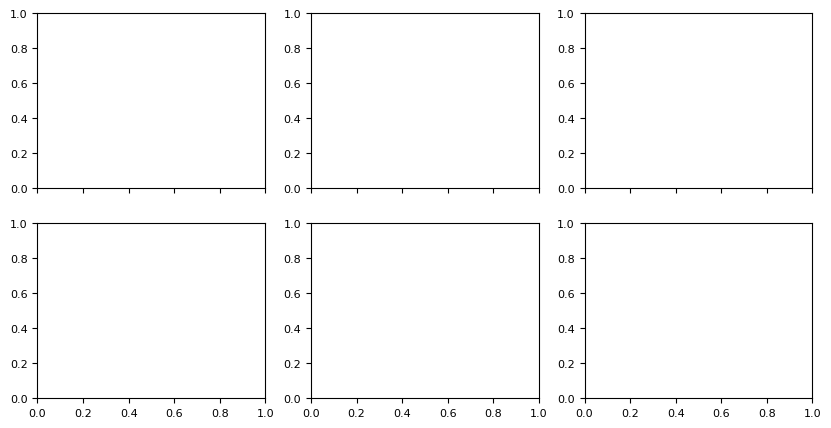

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex=True)
colors = sample_colors(8)
time_interval = (-5, 5)

# where the session field ends with MCC
for m, monkey in enumerate(["ka", "po"]):
    for s, subregion in enumerate(['MCC', 'dLPFC', 'vLPFC']):
        ax = axs[m, s]

        trajectories_temp = trajectories.sel(session=(trajectories.session.str.endswith(subregion)) & (trajectories.session.str.startswith(monkey)))
        #trajectories_temp = value_sessions(trajectories_temp)
        trajectories_temp = trajectories_temp.sel(time=slice(*time_interval))

        if len(trajectories_temp) == 0:
            print(f'No value sessions for {monkey} {subregion}')
            continue
        for fb_seq in np.unique(trajectories.fb_sequence.values):
            data = trajectories_temp.sel(fb_sequence=fb_seq).mean(dim='session').values
            data_smooth = np.convolve(data, np.ones(5)/5, mode='same')

            ax.plot(trajectories_temp.time, data_smooth, label=f'{monkey} {subregion} {fb_seq}', color=colors[int(fb_seq)])

            plot_keypoints(ax, (-1, 0), mark_event='Fb')
            ax.grid(axis='x', linestyle='--', alpha=0.5)

        ax.set_title(f'{monkey} {subregion}, n={len(trajectories_temp)}')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_xlim(time_interval)


# save figure
fig.suptitle(f'Neural Value Projection, all sess. avg.', fontsize=10)
fig.savefig(f'figs/neural_value/all_sessions_projection.svg', bbox_inches='tight', transparent=True)

In [ ]:
decodability_matrix

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
cmap = plt.get_cmap('RdBu')
time_interval = (-5, 5)

# where the session field ends with MCC
for m, monkey in enumerate(["ka", "po"]):
    for s, subregion in enumerate(['MCC', 'dLPFC', 'vLPFC']):
        ax = axs[m, s]

        matrix_temp = decodability_matrix.sel(session=(decodability_matrix.session.str.endswith(subregion)) & (decodability_matrix.session.str.startswith(monkey)))
        matrix_temp = matrix_temp.sel(train_time=slice(*time_interval), test_time=slice(*time_interval))
        matrix_temp = matrix_temp.mean(dim='session').values

        #ax.plot(matrix_temp.time, data, label=f'{monkey} {subregion} {fb_seq}', color=cmap(fb_seq / len(np.unique(decodability_matrix.fb_sequence.values))))
        v_extreme = np.max(np.abs(matrix_temp))
        vmin = .5 - (v_extreme - .5)
        vmax = .5 + (v_extreme - .5)
        pbar = ax.imshow(matrix_temp, aspect='auto', cmap=cmap, extent=[time_interval[0], time_interval[1], time_interval[0], time_interval[1]], origin='lower', vmin=vmin, vmax=vmax)
        plt.colorbar(pbar, ax=ax)

        plot_keypoints(ax, (-1, 0), axis='both', mark_event='Fb')
        ax.grid(linestyle='--', alpha=0.5)

        ax.set_title(f'{monkey} {subregion}')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_xlim(time_interval)
        ax.set_ylim(time_interval)

# save figure
fig.suptitle(f'Neural Value Decodability Matrix, all sess. avg.', fontsize=10)
fig.savefig(f'figs/neural_value/all_sessions_decodability_matrix.svg', bbox_inches='tight', transparent=True)
